In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch

import optuna
import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
representation_type = "integrated_syntactic_graph_element-wise"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "graph"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

train_data_isg_path = current_dir.parent.parent / "data" / "01_processed" / "training-vectors-isg.dat"
val_data_isg_path = current_dir.parent.parent / "data" / "01_processed" / "val-vectors-isg.dat"
test_data_isg_path = current_dir.parent.parent / "data" / "01_processed" / "test-vectors-isg.dat"

Connect to databricks for logging results

In [6]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/22 15:47:50 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/12/22 15:47:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/22 15:47:50 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/22 15:47:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/22 15:47:50 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [7]:
mlflow.sklearn.autolog(disable=True)
mlflow.xgboost.autolog(disable=True)

What are GPU are the experiments run on

In [8]:
!nvidia-smi

Mon Dec 22 15:47:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:A3:00.0 Off |                    0 |
|  0%   55C    P0            116W /  300W |     271MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

89

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Set the constant for the dimension size

In [13]:
isg_vector_dimension = 35488

# Load dataset

### Load training data

In [14]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [00:24<00:00, 460MB/s]


Successfully loaded 273301 items.


In [15]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [16]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


In [17]:
train_data_df = train_data_df.head(100)

##### Load the integrated graph vectors for training

In [18]:
train_embeddings = np.memmap(
    train_data_isg_path,
    dtype="float32",
    mode="r",      
    shape = (len(train_data_df), 2, isg_vector_dimension)
    )

### Load validation data

In [19]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:00<00:00, 430MB/s] 


Successfully loaded 2500 items.


In [20]:
val_data_df = pd.DataFrame(val_data)

In [21]:
val_data_df = val_data_df.head(100)

##### Load the integrated graph vectors for validation

In [22]:
val_embeddings = np.memmap(
    val_data_isg_path,
    dtype="float32",
    mode="r",      
    shape = (len(val_data_df), 2, isg_vector_dimension)
    )

### Combine the training and validation data for the final classifier training

##### Combine the dataframes

In [23]:
combined_train_val_data_df = pd.concat(
    [train_data_df, val_data_df],
    axis=0,
    ignore_index=True
)

##### Combine the vectors

In [24]:
combined_train_val_embeddings = np.concatenate(
    [train_embeddings, val_embeddings],
    axis=0
)

### Load testing data

In [25]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 463MB/s] 


Successfully loaded 19999 items.


In [26]:
test_data_df = pd.DataFrame(test_data)

In [27]:
test_data_df = test_data_df.head(100)

##### Load the integrated graph vectors for training

In [28]:
test_embeddings = np.memmap(
    test_data_isg_path,
    dtype="float32",
    mode="r",      
    shape = (len(test_data_df), 2, isg_vector_dimension)
    )

Prepare training & val & testing data

In [29]:
X_train = (
    train_embeddings[:, 0, :] * train_embeddings[:, 1, :]
)

X_val = (
    val_embeddings[:, 0, :] * val_embeddings[:, 1, :]
)

X_test = (
    test_embeddings[:, 0, :] * test_embeddings[:, 1, :]
)

X_train_val = (
    combined_train_val_embeddings[:, 0, :]
    * combined_train_val_embeddings[:, 1, :]
)

Prepare training & val & testing labels

In [30]:
y_train = train_data_df["same"].values
y_val = val_data_df["same"].values
y_test = test_data_df["same"].values
y_train_val = combined_train_val_data_df["same"].values

# Evaluation functions

Evaluation function

In [31]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Create the confusion matrix

In [32]:
def plot_confusion_matrix(y_true, y_pred, model_id="", labels=[False, True]):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')

    plt.tight_layout()
    return fig

Create histogram of F1 score for different thresholds

In [33]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

# Classifier config setup for optuna studies

In [34]:
class ClassifierConfig: 
    def __init__(self, classifier_object, searched_hyperparameters, fixed_hyperparameters=None):
        self.classifier_object = classifier_object
        self.searched_hyperparameters = searched_hyperparameters or {}
        self.fixed_hyperparameters = fixed_hyperparameters or {}

    def sample_params(self, trial):
        sampled = {
            name: fn(trial)
            for name, fn in self.searched_hyperparameters.items()
        }
        sampled.update(self.fixed_hyperparameters)
        return sampled

In [35]:
def objective(trial, config):
    #get the classifier hyperparameters
    classifier_params = config.sample_params(trial)

    #set up classifier
    classifier = config.classifier_object(**classifier_params)
    
    #Fit the classifier
    classifier.fit(X_train, y_train)
    
    #predict the labels for the test data
    y_pred = classifier.predict(X_val)
    
    top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_val, y_pred)

    print(f"Logging results \n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    trial.set_user_attr(
    "results",
    {
    "metrics": {
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
        },
    "classifier_hyperparameters": {
            **classifier_params
        },
    }
    )
    print(classifier_params)
    del classifier

    return top_f1   

# Evaluate model hyperparameters - Multinomial naïve Bayes

In [36]:
classifier_name = "multinomial_naive_bayes"

In [37]:
multinomial_naive_bayes_config = ClassifierConfig(
    classifier_object=MultinomialNB,
    searched_hyperparameters={
        "alpha": lambda trial: trial.suggest_float("alpha", 1e-3, 1.0, log=True)
    },
    fixed_hyperparameters={}
)

Set up the study

In [38]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 15:48:19,649] A new study created in RDB with name: authorship_verification_integrated_syntactic_graph_element-wise_multinomial_naive_bayes


In [39]:
study.optimize(lambda trial: objective(trial, multinomial_naive_bayes_config), n_trials=30-len(study.trials), show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'alpha': 0.12889934609518658}
[I 2025-12-22 15:48:19,875] Trial 0 finished with value: 50.0 and parameters: {'alpha': 0.12889934609518658}. Best is trial 0 with value: 50.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'alpha': 0.08272008818868887}
[I 2025-12-22 15:48:20,064] Trial 1 finished with value: 50.0 and parameters: {'alpha': 0.08272008818868887}. Best is trial 0 with value: 50.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'alpha': 0.9448049649011335}
[I 2025-12-22 15:48:20,240] Trial 2 finished with value: 50.0 and parameters: {'alpha': 0.9448049649011335}. Best is trial 0 with value: 50.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'alpha': 0.1379596266083708}
[I 2025-12-22 15:48:20,417] Trial 3 finished with value: 50.0 and param

Save the study insights

In [40]:
best_trial = study.best_trial
best_params = best_trial.params

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "graph" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [41]:
trial_rows = []

for trial in study.trials:
    
    metrics = trial.user_attrs["results"]["metrics"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,alpha
0,0,50.0,53.66,41.51,46.81,0.128899
1,1,50.0,53.66,41.51,46.81,0.082720
2,2,50.0,53.66,41.51,46.81,0.944805
3,3,50.0,53.66,41.51,46.81,0.137960
4,4,50.0,53.66,41.51,46.81,0.005472


In [42]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [43]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Multinomial naïve Bayes

In [44]:
best_params = {}
trial_results = {}

In [45]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [46]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [47]:
trial_results_df = pd.DataFrame(trial_results)

In [48]:
top_alpha = best_params["alpha"]

In [49]:
print(f"Used hyperparameters \n")
print(f"alpha: {top_alpha}\n")

Used hyperparameters 

alpha: 0.12889934609518658



Compute the absolute differences between the pairs of features in train and test data

Fit the classifier

In [50]:
classifier = MultinomialNB(alpha=top_alpha)
classifier.fit(X_train_val, y_train_val)

MultinomialNB(alpha=0.12889934609518658)

Predict the labels for the test data

In [51]:
y_pred = classifier.predict(X_test)

Evaluate the results of the final classifier

In [52]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 49.0

Top accuracy: 48.98

Top precision: 48.0

Top recall: 48.48



Save the final vectorizer and classifier

In [53]:
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/graph/JP_integrated_syntactic_graph_element-wise_multinomial_naive_bayes_best_model.pkl']

Confusion matrix

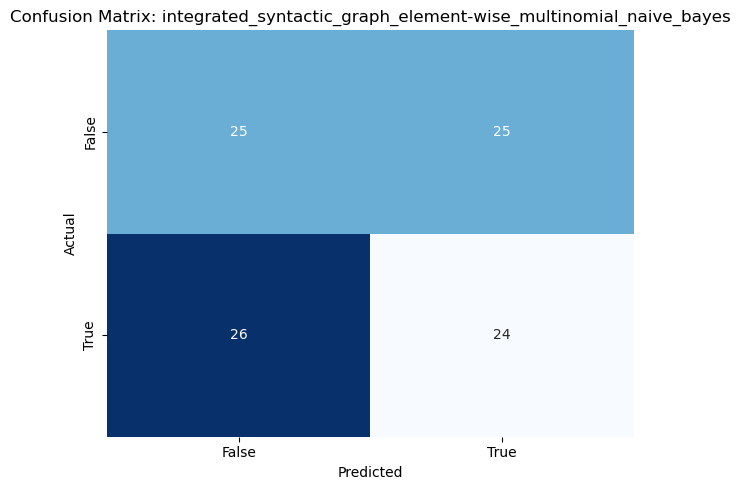

In [54]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [55]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("alpha", top_alpha)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_integrated_syntactic_graph_element-wise_multinomial_naive_bayes at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/fa8a09988c8649f49210d99dcbcc6614
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Logistic regression

In [56]:
classifier_name = "logistic_regression"

Resolving the penalty parameter - for both types only certain solvers are possible

In [57]:
logistic_regression_config = ClassifierConfig(
    classifier_object=LogisticRegression,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "penalty": lambda trial: trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": lambda trial: trial.suggest_categorical("solver", ["liblinear", "saga"]),
    },
    fixed_hyperparameters={
        "max_iter": 5000,
        "n_jobs": -1 #uses all cores
    }
)

Set up the study

In [58]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)



[I 2025-12-22 15:48:31,418] A new study created in RDB with name: authorship_verification_integrated_syntactic_graph_element-wise_logistic_regression


In [59]:
len(study.trials)

0

In [60]:
study.optimize(lambda trial: objective(trial, logistic_regression_config), n_trials=30-len(study.trials), show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(


Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'C': 0.06479156598980683, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:31,805] Trial 0 finished with value: 50.0 and parameters: {'C': 0.06479156598980683, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 0 with value: 50.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'C': 0.08305497234662781, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:33,229] Trial 1 finished with value: 50.0 and parameters: {'C': 0.08305497234662781, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 0 with value: 50.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'C': 0.03876815979627229, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:34,404] Trial 2 finished with value: 50.0 and parameters

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(


Logging results 

Top f1: 62.0

Top accuracy: 68.29

Top precision: 52.83

Top recall: 59.57

{'C': 2.3425968351450237, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:37,807] Trial 5 finished with value: 62.0 and parameters: {'C': 2.3425968351450237, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 5 with value: 62.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'C': 3.814862610142402, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:39,519] Trial 6 finished with value: 50.0 and parameters: {'C': 3.814862610142402, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 5 with value: 62.0.
Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'C': 3.0940890706220276, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:40,749] Trial 7 finished with value: 50.0 and parameters: {'C':

...

Logging results 

Top f1: 60.0

Top accuracy: 66.67

Top precision: 49.06

Top recall: 56.52

{'C': 0.5942840269016381, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:53,590] Trial 27 finished with value: 60.0 and parameters: {'C': 0.5942840269016381, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 19 with value: 64.0.


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(


Logging results 

Top f1: 49.0

Top accuracy: 51.85

Top precision: 52.83

Top recall: 52.34

{'C': 0.15242287449872707, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:53,906] Trial 28 finished with value: 49.0 and parameters: {'C': 0.15242287449872707, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 19 with value: 64.0.


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(


Logging results 

Top f1: 50.0

Top accuracy: 53.66

Top precision: 41.51

Top recall: 46.81

{'C': 0.027033890167803186, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
[I 2025-12-22 15:48:54,147] Trial 29 finished with value: 50.0 and parameters: {'C': 0.027033890167803186, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 19 with value: 64.0.


Save the study insights

In [61]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "max_iter": 5000,
    "n_jobs": -1
})

In [62]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "graph" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [63]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,C,penalty,solver,max_iter,n_jobs
0,0,50.0,53.66,41.51,46.81,0.064792,l2,liblinear,5000,-1
1,1,50.0,53.66,41.51,46.81,0.083055,l1,saga,5000,-1
2,2,50.0,53.66,41.51,46.81,0.038768,l2,saga,5000,-1
3,3,50.0,53.66,41.51,46.81,0.699040,l1,saga,5000,-1
4,4,50.0,53.66,41.51,46.81,0.475247,l1,saga,5000,-1


In [64]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [65]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Logistic regression

In [66]:
best_params = {}
trial_results = {}

In [67]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [68]:
print(best_params)

{'C': 4.8533925114282415, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


In [69]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [70]:
trial_results_df = pd.DataFrame(trial_results)

In [71]:
top_c = best_params["C"]
top_penalty = best_params["penalty"]
top_solver = best_params["solver"]
top_max_iter = best_params["max_iter"]
top_n_jobs = best_params["n_jobs"]

In [72]:
print(f"Used hyperparameters \n")
print(f"c: {top_c}\n")
print(f"penalty: {top_penalty}\n")
print(f"solver: {top_solver}\n")
print(f"max_iter: {top_max_iter}\n")
print(f"n_jobs: {top_n_jobs}\n")

Used hyperparameters 

c: 4.8533925114282415

penalty: l1

solver: liblinear

max_iter: 5000

n_jobs: -1



Fit the classifier

In [73]:
classifier = LogisticRegression(
    C=top_c,
    penalty=top_penalty,
    solver=top_solver,
    max_iter=top_max_iter,
    n_jobs=top_n_jobs
)
classifier.fit(X_train_val, y_train_val)

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(


LogisticRegression(C=4.8533925114282415, max_iter=5000, n_jobs=-1, penalty='l1',
                   solver='liblinear')

Predict the labels for the test data

In [74]:
y_pred = classifier.predict(X_test)

Evaluate the results of the final classifier

In [75]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 51.0

Top accuracy: 51.06

Top precision: 48.0

Top recall: 49.48



Save the final vectorizer and classifier

In [76]:
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/graph/JP_integrated_syntactic_graph_element-wise_logistic_regression_best_model.pkl']

Confusion matrix

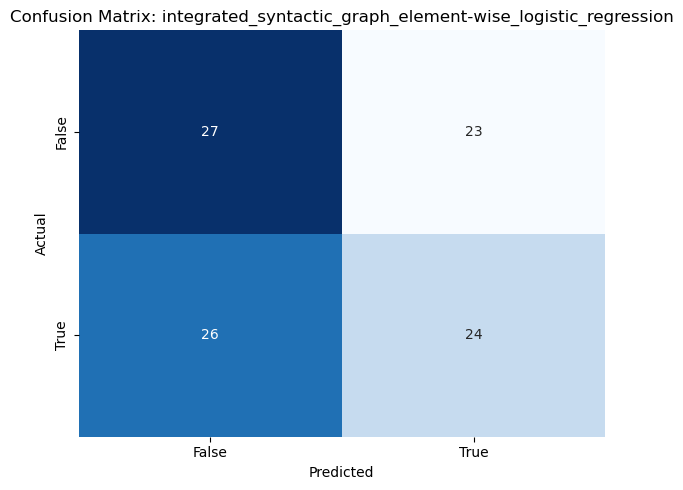

In [77]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [78]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("C", top_c)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("solver", top_solver)
    mlflow.log_param("max_iter", top_max_iter)
    mlflow.log_param("n_jobs", top_n_jobs)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_integrated_syntactic_graph_element-wise_logistic_regression at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/b2e8341efe5f4a20b85f9ed89141b1e7
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Linear SVC

In [79]:
classifier_name = "linear_svc"

In [80]:
linear_svc_config = ClassifierConfig(
    classifier_object=LinearSVC,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "loss": lambda trial: trial.suggest_categorical("loss", ["hinge", "squared_hinge"]),
        "class_weight": lambda trial: trial.suggest_categorical("class_weight", [None, "balanced"]),
    },
    fixed_hyperparameters={
        "penalty": "l2",       # LinearSVC ONLY supports l2
        "dual": True,          # for high-dimensional data (TF-IDF)
        "max_iter": 5000       # ensure convergence
    }
)

Set up the study

In [81]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 15:49:02,509] A new study created in RDB with name: authorship_verification_integrated_syntactic_graph_element-wise_linear_svc


In [82]:
study.optimize(lambda trial: objective(trial, linear_svc_config), n_trials=30, show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

{'C': 0.030938265507786295, 'loss': 'squared_hinge', 'class_weight': None, 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
[I 2025-12-22 15:49:03,060] Trial 0 finished with value: 47.0 and parameters: {'C': 0.030938265507786295, 'loss': 'squared_hinge', 'class_weight': None}. Best is trial 0 with value: 47.0.


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logging results 

Top f1: 53.0

Top accuracy: 53.0

Top precision: 100.0

Top recall: 69.28

{'C': 2.073362849126759, 'loss': 'hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
[I 2025-12-22 15:49:03,556] Trial 1 finished with value: 53.0 and parameters: {'C': 2.073362849126759, 'loss': 'hinge', 'class_weight': 'balanced'}. Best is trial 1 with value: 53.0.


...

Logging results 

Top f1: 53.0

Top accuracy: 53.0

Top precision: 100.0

Top recall: 69.28

{'C': 0.8776896169038773, 'loss': 'hinge', 'class_weight': None, 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
[I 2025-12-22 15:49:15,629] Trial 27 finished with value: 53.0 and parameters: {'C': 0.8776896169038773, 'loss': 'hinge', 'class_weight': None}. Best is trial 1 with value: 53.0.


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logging results 

Top f1: 51.0

Top accuracy: 52.22

Top precision: 88.68

Top recall: 65.73

{'C': 3.1148757872807646, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
[I 2025-12-22 15:49:16,088] Trial 28 finished with value: 51.0 and parameters: {'C': 3.1148757872807646, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 1 with value: 53.0.


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logging results 

Top f1: 46.0

Top accuracy: 42.86

Top precision: 5.66

Top recall: 10.0

{'C': 0.04839332903432124, 'loss': 'squared_hinge', 'class_weight': None, 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
[I 2025-12-22 15:49:16,527] Trial 29 finished with value: 46.0 and parameters: {'C': 0.04839332903432124, 'loss': 'squared_hinge', 'class_weight': None}. Best is trial 1 with value: 53.0.


Save the study insights

In [83]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "penalty": "l2",       
    "dual": True,          
    "max_iter": 5000
})


In [84]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "graph" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [85]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,C,loss,class_weight,penalty,dual,max_iter
0,0,47.0,0.0,0.0,0.00,0.030938,squared_hinge,None,l2,True,5000
1,1,53.0,53.0,100.0,69.28,2.073363,hinge,balanced,l2,True,5000
2,2,53.0,53.0,100.0,69.28,0.015753,squared_hinge,None,l2,True,5000
3,3,53.0,53.0,100.0,69.28,4.544252,hinge,None,l2,True,5000
4,4,47.0,0.0,0.0,0.00,0.052000,hinge,balanced,l2,True,5000


In [86]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [87]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Linear SVC

In [88]:
best_params = {}
trial_results = {}

In [89]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [90]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [91]:
trial_results_df = pd.DataFrame(trial_results)

In [92]:
top_c = best_params["C"]
top_loss = best_params["loss"]
top_class_weight = best_params["class_weight"]
top_penalty = best_params["penalty"]
top_dual = best_params["dual"]
top_max_iter = best_params["max_iter"]

In [93]:
print(f"Used hyperparameters \n")

print(f"c: {top_c}\n")
print(f"loss: {top_loss}\n")
print(f"class_weight: {top_class_weight}\n")
print(f"penalty: {top_penalty}\n")
print(f"dual: {top_dual}\n")
print(f"max_iter: {top_max_iter}\n")

Used hyperparameters 

c: 2.073362849126759

loss: hinge

class_weight: balanced

penalty: l2

dual: True

max_iter: 5000



Fit the classifier

In [94]:
classifier = LinearSVC(
    C=top_c,
    loss=top_loss,
    class_weight=top_class_weight,
    penalty=top_penalty,
    dual=top_dual,
    max_iter=top_max_iter
)

classifier.fit(X_train_val, y_train_val)

/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=2.073362849126759, class_weight='balanced', dual=True, loss='hinge',
          max_iter=5000)

Predict the labels for the test data

In [95]:
y_pred = classifier.predict(X_test)

Evaluate the results of the final classifier

In [96]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 49.0

Top accuracy: 48.98

Top precision: 48.0

Top recall: 48.48



Save the final vectorizer and classifier

In [97]:
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/graph/JP_integrated_syntactic_graph_element-wise_linear_svc_best_model.pkl']

Confusion matrix

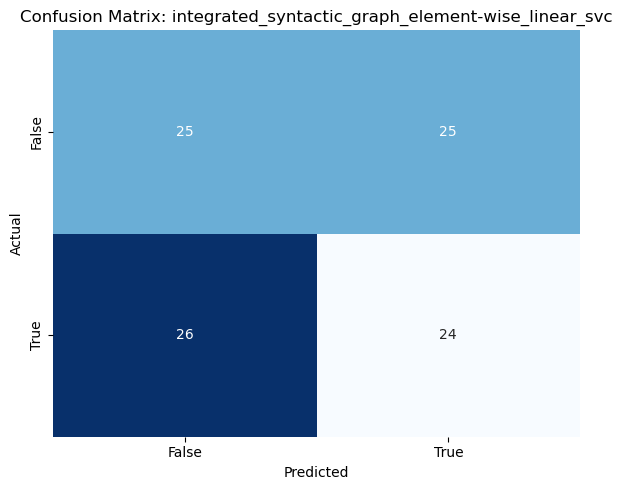

In [98]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [99]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
                    
    mlflow.log_param("C", top_c)
    mlflow.log_param("loss", top_loss)
    mlflow.log_param("class_weight", top_class_weight)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("dual", top_dual)
    mlflow.log_param("max_iter", top_max_iter)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_integrated_syntactic_graph_element-wise_linear_svc at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/a28065167ac14789ae8b8257e0883993
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - K-nearest neighbors

In [100]:
classifier_name = "k-nearest_neighbors"

In [101]:
knn_config = ClassifierConfig(
    classifier_object=KNeighborsClassifier,
    searched_hyperparameters={
        "n_neighbors": lambda trial: trial.suggest_int("n_neighbors", 1, 50),
        "weights": lambda trial: trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": lambda trial: trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
    },
    fixed_hyperparameters={
        "algorithm": "auto"
    }
)

Set up the study

In [102]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 15:49:23,474] A new study created in RDB with name: authorship_verification_integrated_syntactic_graph_element-wise_k-nearest_neighbors


In [103]:
study.optimize(lambda trial: objective(trial, knn_config), n_trials=30-len(study.trials), show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

Logging results 

Top f1: 51.0

Top accuracy: 54.55

Top precision: 45.28

Top recall: 49.48

{'n_neighbors': 34, 'weights': 'distance', 'metric': 'manhattan', 'algorithm': 'auto'}
[I 2025-12-22 15:49:24,121] Trial 0 finished with value: 51.0 and parameters: {'n_neighbors': 34, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 51.0.
Logging results 

Top f1: 52.0

Top accuracy: 55.56

Top precision: 47.17

Top recall: 51.02

{'n_neighbors': 24, 'weights': 'distance', 'metric': 'manhattan', 'algorithm': 'auto'}
[I 2025-12-22 15:49:24,789] Trial 1 finished with value: 52.0 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 52.0.
Logging results 

Top f1: 54.0

Top accuracy: 57.78

Top precision: 49.06

Top recall: 53.06

{'n_neighbors': 50, 'weights': 'distance', 'metric': 'manhattan', 'algorithm': 'auto'}
[I 2025-12-22 15:49:25,474] Trial 2 finished with value: 54.0 and parameters: {'n_neighbors': 50, '

Save the study insights

In [104]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "algorithm": "auto"
})

In [105]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "graph" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [106]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,n_neighbors,weights,metric,algorithm
0,0,51.0,54.55,45.28,49.48,34,distance,manhattan,auto
1,1,52.0,55.56,47.17,51.02,24,distance,manhattan,auto
2,2,54.0,57.78,49.06,53.06,50,distance,manhattan,auto
3,3,61.0,69.44,47.17,56.18,23,uniform,cosine,auto
4,4,53.0,62.50,28.30,38.96,41,uniform,euclidean,auto


In [107]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [108]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - K-nearest neighbors

In [109]:
best_params = {}
trial_results = {}

In [110]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [111]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [112]:
trial_results_df = pd.DataFrame(trial_results)

In [113]:
top_n_neighbors = best_params["n_neighbors"]
top_weights = best_params["weights"]
top_metric = best_params["metric"]
top_algorithm = best_params["algorithm"]

In [114]:
print(f"Used hyperparameters \n")

print(f"n_neighbors: {top_n_neighbors}\n")
print(f"weights: {top_weights}\n")
print(f"metric: {top_metric}\n")
print(f"algorithm: {top_algorithm}\n")

Used hyperparameters 

n_neighbors: 23

weights: uniform

metric: cosine

algorithm: auto



Fit the classifier

In [115]:
classifier = KNeighborsClassifier(
    n_neighbors=top_n_neighbors,
    weights=top_weights,
    metric=top_metric,
    algorithm=top_algorithm
)

classifier.fit(X_train_val, y_train_val)

KNeighborsClassifier(metric='cosine', n_neighbors=23)

Predict the labels for the test data

In [116]:
y_pred = classifier.predict(X_test)

Evaluate the results of the final classifier

In [117]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 44.0

Top accuracy: 44.64

Top precision: 50.0

Top recall: 47.17



Save the final vectorizer and classifier

In [118]:
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/graph/JP_integrated_syntactic_graph_element-wise_k-nearest_neighbors_best_model.pkl']

Confusion matrix

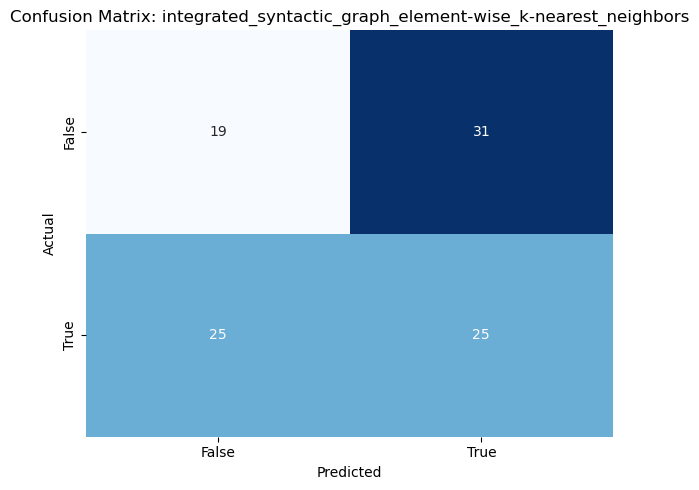

In [119]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [120]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
                    
    mlflow.log_param("n_neighbors", top_n_neighbors)
    mlflow.log_param("weights", top_weights)
    mlflow.log_param("metric", top_metric)
    mlflow.log_param("algorithm", top_algorithm)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_integrated_syntactic_graph_element-wise_k-nearest_neighbors at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/d928105f0639461fbf5ac0c7dbd39396
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Random Forest

In [121]:
classifier_name = "random_forest"

In [122]:
random_forest_config = ClassifierConfig(
    classifier_object=RandomForestClassifier,
    searched_hyperparameters={
        "n_estimators": lambda trial: trial.suggest_int("n_estimators", 100, 600),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": lambda trial: trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": lambda trial: trial.suggest_int("min_samples_leaf", 1, 10)
    },
    fixed_hyperparameters={
        "n_jobs": -1,        # use all cores
        "random_state": 42   # reproducible forests
    }
)

Set up the study

In [123]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 15:49:44,293] A new study created in RDB with name: authorship_verification_integrated_syntactic_graph_element-wise_random_forest


In [124]:
study.optimize(lambda trial: objective(trial, random_forest_config), n_trials=30-len(study.trials), show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

Logging results 

Top f1: 61.0

Top accuracy: 100.0

Top precision: 26.42

Top recall: 41.79

{'n_estimators': 501, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 5, 'n_jobs': -1, 'random_state': 42}
[I 2025-12-22 15:49:46,289] Trial 0 finished with value: 61.0 and parameters: {'n_estimators': 501, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 0 with value: 61.0.
Logging results 

Top f1: 60.0

Top accuracy: 100.0

Top precision: 24.53

Top recall: 39.39

{'n_estimators': 465, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 5, 'n_jobs': -1, 'random_state': 42}
[I 2025-12-22 15:49:47,821] Trial 1 finished with value: 60.0 and parameters: {'n_estimators': 465, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 0 with value: 61.0.
Logging results 

Top f1: 60.0

Top accuracy: 88.24

Top precision: 28.3

Top recall: 42.86

{'n_estimators': 452, 'max_depth': 25, 'min_samples_split': 16, 'min_samples_leaf

Save the study insights

In [125]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "n_jobs": -1,        
    "random_state": 42   
})


In [126]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "graph" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [127]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,n_estimators,max_depth,min_samples_split,min_samples_leaf,n_jobs,random_state
0,0,61.0,100.00,26.42,41.79,501,23,9,5,-1,42
1,1,60.0,100.00,24.53,39.39,465,15,9,5,-1,42
2,2,60.0,88.24,28.30,42.86,452,25,16,2,-1,42
3,3,54.0,88.89,15.09,25.81,347,32,16,9,-1,42
4,4,63.0,78.57,41.51,54.32,111,45,16,6,-1,42


In [128]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [129]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Random forest

In [130]:
best_params = {}
trial_results = {}

In [131]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [132]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [133]:
trial_results_df = pd.DataFrame(trial_results)

In [134]:
top_n_estimators = best_params["n_estimators"]
top_max_depth = best_params["max_depth"]
top_min_samples_split = best_params["min_samples_split"]
top_min_samples_leaf = best_params["min_samples_leaf"]
top_n_jobs = best_params["n_jobs"]
top_random_state = best_params["random_state"]

In [135]:
print(f"Used hyperparameters \n")

print(f"n_estimators: {top_n_estimators}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"min_samples_split: {top_min_samples_split}\n")
print(f"min_samples_leaf: {top_min_samples_leaf}\n")
print(f"n_jobs: {top_n_jobs}\n")
print(f"random_state: {top_random_state}\n")

Used hyperparameters 

n_estimators: 110

max_depth: 35

min_samples_split: 14

min_samples_leaf: 6

n_jobs: -1

random_state: 42



Fit the classifier

In [136]:
classifier = RandomForestClassifier(
    n_estimators=top_n_estimators,
    max_depth=top_max_depth,
    min_samples_split=top_min_samples_split,
    min_samples_leaf=top_min_samples_leaf,
    n_jobs=top_n_jobs,
    random_state=top_random_state
)

classifier.fit(X_train_val, y_train_val)

RandomForestClassifier(max_depth=35, min_samples_leaf=6, min_samples_split=14,
                       n_estimators=110, n_jobs=-1, random_state=42)

Predict the labels for the test data

In [137]:
y_pred = classifier.predict(X_test)

Evaluate the results of the final classifier

In [138]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 53.0

Top accuracy: 53.49

Top precision: 46.0

Top recall: 49.46



Save the final vectorizer and classifier

In [139]:
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/graph/JP_integrated_syntactic_graph_element-wise_random_forest_best_model.pkl']

Confusion matrix

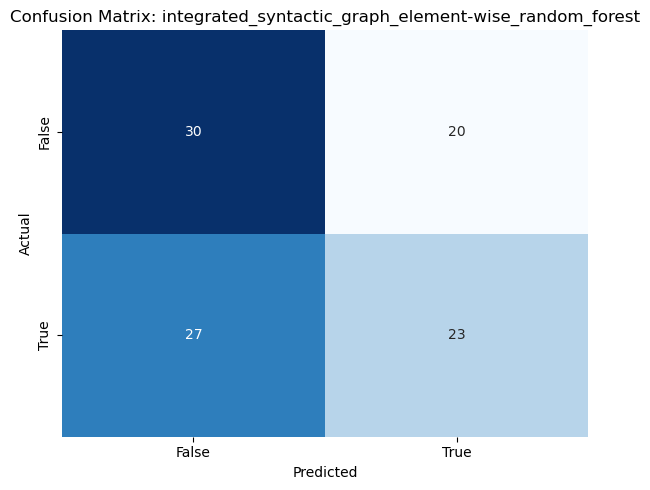

In [140]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [141]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
                    
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("min_samples_split", top_min_samples_split)
    mlflow.log_param("min_samples_leaf", top_min_samples_leaf)
    mlflow.log_param("n_jobs", top_n_jobs)
    mlflow.log_param("random_state", top_random_state)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_integrated_syntactic_graph_element-wise_random_forest at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/82a1eaeab99c4f3eab2e76bf8dd352fb
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters- XGBoost

In [142]:
classifier_name = "xgboost"

In [143]:
xgboost_config = ClassifierConfig(
    classifier_object=XGBClassifier,
    searched_hyperparameters={
        "eta": lambda trial: trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 3, 12),
        "subsample": lambda trial: trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda trial: trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": lambda trial: trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": lambda trial: trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
    },
    fixed_hyperparameters={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_estimators": 300,     
        "tree_method": "auto", 
        "use_label_encoder": False
    }
)

Set up the study

In [144]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-22 15:50:22,037] A new study created in RDB with name: authorship_verification_integrated_syntactic_graph_element-wise_xgboost


In [145]:
study.optimize(lambda trial: objective(trial, xgboost_config), n_trials=30-len(study.trials), show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:50:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logging results 

Top f1: 65.0

Top accuracy: 72.5

Top precision: 54.72

Top recall: 62.37

{'eta': 0.255329671801525, 'max_depth': 3, 'subsample': 0.7839207578142051, 'colsample_bytree': 0.9273143052834114, 'reg_lambda': 0.0011438422927350746, 'reg_alpha': 0.38781637684794495, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
[I 2025-12-22 15:50:24,831] Trial 0 finished with value: 65.0 and parameters: {'eta': 0.255329671801525, 'max_depth': 3, 'subsample': 0.7839207578142051, 'colsample_bytree': 0.9273143052834114, 'reg_lambda': 0.0011438422927350746, 'reg_alpha': 0.38781637684794495}. Best is trial 0 with value: 65.0.


/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:50:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logging results 

Top f1: 62.0

Top accuracy: 66.67

Top precision: 56.6

Top recall: 61.22

{'eta': 0.13595959190616597, 'max_depth': 11, 'subsample': 0.9377754925802934, 'colsample_bytree': 0.9633609065281046, 'reg_lambda': 0.008471257933076296, 'reg_alpha': 0.15214465071902153, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
[I 2025-12-22 15:50:27,560] Trial 1 finished with value: 62.0 and parameters: {'eta': 0.13595959190616597, 'max_depth': 11, 'subsample': 0.9377754925802934, 'colsample_bytree': 0.9633609065281046, 'reg_lambda': 0.008471257933076296, 'reg_alpha': 0.15214465071902153}. Best is trial 0 with value: 65.0.


...

Logging results 

Top f1: 66.0

Top accuracy: 71.11

Top precision: 60.38

Top recall: 65.31

{'eta': 0.02886344610143863, 'max_depth': 6, 'subsample': 0.6159057380407917, 'colsample_bytree': 0.7695891971670111, 'reg_lambda': 2.307470399338758, 'reg_alpha': 0.05646301680461781, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
[I 2025-12-22 15:51:43,111] Trial 27 finished with value: 66.0 and parameters: {'eta': 0.02886344610143863, 'max_depth': 6, 'subsample': 0.6159057380407917, 'colsample_bytree': 0.7695891971670111, 'reg_lambda': 2.307470399338758, 'reg_alpha': 0.05646301680461781}. Best is trial 18 with value: 71.0.


/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:51:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logging results 

Top f1: 64.0

Top accuracy: 70.73

Top precision: 54.72

Top recall: 61.7

{'eta': 0.08501354830461183, 'max_depth': 8, 'subsample': 0.5518246001476053, 'colsample_bytree': 0.8550671260346262, 'reg_lambda': 7.537073257632493, 'reg_alpha': 0.010304748426047013, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
[I 2025-12-22 15:51:46,344] Trial 28 finished with value: 64.0 and parameters: {'eta': 0.08501354830461183, 'max_depth': 8, 'subsample': 0.5518246001476053, 'colsample_bytree': 0.8550671260346262, 'reg_lambda': 7.537073257632493, 'reg_alpha': 0.010304748426047013}. Best is trial 18 with value: 71.0.


/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:51:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logging results 

Top f1: 67.0

Top accuracy: 72.73

Top precision: 60.38

Top recall: 65.98

{'eta': 0.052699866607483756, 'max_depth': 10, 'subsample': 0.7533316614460247, 'colsample_bytree': 0.9263515355530617, 'reg_lambda': 0.07284693847833061, 'reg_alpha': 0.004236573213735053, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
[I 2025-12-22 15:51:49,479] Trial 29 finished with value: 67.0 and parameters: {'eta': 0.052699866607483756, 'max_depth': 10, 'subsample': 0.7533316614460247, 'colsample_bytree': 0.9263515355530617, 'reg_lambda': 0.07284693847833061, 'reg_alpha': 0.004236573213735053}. Best is trial 18 with value: 71.0.


Save the study insights

In [146]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 300,     
    "tree_method": "auto", 
    "use_label_encoder": False
})

In [147]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "graph" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "graph" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [148]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,eta,max_depth,subsample,colsample_bytree,reg_lambda,reg_alpha,objective,eval_metric,n_estimators,tree_method,use_label_encoder
0,0,65.0,72.50,54.72,62.37,0.255330,3,0.783921,0.927314,0.001144,0.387816,binary:logistic,logloss,300,auto,False
1,1,62.0,66.67,56.60,61.22,0.135960,11,0.937775,0.963361,0.008471,0.152145,binary:logistic,logloss,300,auto,False
2,2,64.0,70.73,54.72,61.70,0.255390,5,0.546811,0.566133,0.009793,0.098141,binary:logistic,logloss,300,auto,False
3,3,62.0,67.44,54.72,60.42,0.227308,9,0.878220,0.504391,0.290995,0.002555,binary:logistic,logloss,300,auto,False
4,4,57.0,63.89,43.40,51.69,0.222478,5,0.503887,0.954548,0.036682,0.004126,binary:logistic,logloss,300,auto,False


In [149]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [150]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - XGBoost

In [151]:
best_params = {}
trial_results = {}

In [152]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [153]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [154]:
trial_results_df = pd.DataFrame(trial_results)

In [155]:
top_eta = best_params["eta"]
top_max_depth = best_params["max_depth"]
top_subsample = best_params["subsample"]
top_colsample_bytree = best_params["colsample_bytree"]
top_reg_lambda = best_params["reg_lambda"]
top_reg_alpha = best_params["reg_alpha"]
top_objective = best_params["objective"]
top_eval_metric = best_params["eval_metric"]
top_n_estimators = best_params["n_estimators"]
top_tree_method = best_params["tree_method"]
top_use_label_encoder = best_params["use_label_encoder"]

In [156]:
print(f"Used hyperparameters \n")

print(f"eta: {top_eta}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"subsample: {top_subsample}\n")
print(f"colsample_bytree: {top_colsample_bytree}\n")
print(f"reg_lambda: {top_reg_lambda}\n")
print(f"reg_alpha: {top_reg_alpha}\n")
print(f"objective: {top_objective}\n")
print(f"eval_metric: {top_eval_metric}\n")
print(f"n_estimators: {top_n_estimators}\n")
print(f"tree_method: {top_tree_method}\n")
print(f"use_label_encoder: {top_use_label_encoder}\n")

Used hyperparameters 

eta: 0.02587092794542664

max_depth: 8

subsample: 0.6074854720764633

colsample_bytree: 0.8047463165161055

reg_lambda: 0.4458232577558827

reg_alpha: 0.007612942444240909

objective: binary:logistic

eval_metric: logloss

n_estimators: 300

tree_method: auto

use_label_encoder: False



Fit the classifier

In [157]:
classifier = XGBClassifier(
    eta=top_eta,
    max_depth=top_max_depth,
    subsample=top_subsample,
    colsample_bytree=top_colsample_bytree,
    reg_lambda=top_reg_lambda,
    reg_alpha=top_reg_alpha,
    objective=top_objective,
    eval_metric=top_eval_metric,
    n_estimators=top_n_estimators,
    tree_method=top_tree_method,
    use_label_encoder=top_use_label_encoder
    
)

classifier.fit(X_train_val, y_train_val)

/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:51:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8047463165161055, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eta=0.02587092794542664, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, ...)

Predict the labels for the test data

In [158]:
y_pred = classifier.predict(X_test)

Evaluate the results of the final classifier

In [159]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 55.0

Top accuracy: 55.56

Top precision: 50.0

Top recall: 52.63



Save the final vectorizer and classifier

In [160]:
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/graph/JP_integrated_syntactic_graph_element-wise_xgboost_best_model.pkl']

Confusion matrix

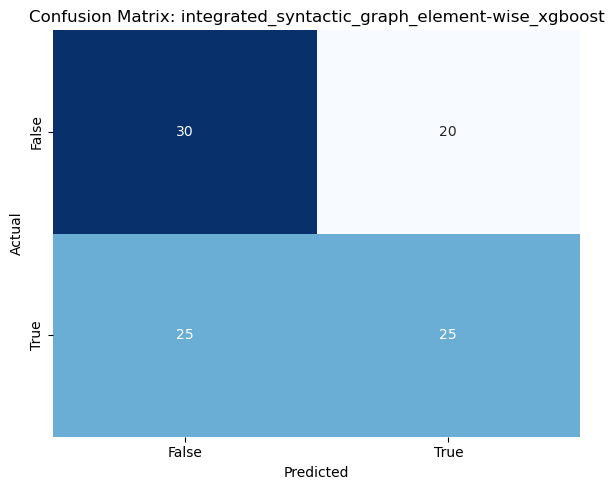

In [161]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [162]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
                    
    mlflow.log_param("eta", top_eta)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("subsample", top_subsample)
    mlflow.log_param("colsample_bytree", top_colsample_bytree)
    mlflow.log_param("reg_lambda", top_reg_lambda)
    mlflow.log_param("reg_alpha", top_reg_alpha)
    mlflow.log_param("objective", top_objective)
    mlflow.log_param("eval_metric", top_eval_metric)
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("tree_method", top_tree_method)
    mlflow.log_param("use_label_encoder", top_use_label_encoder)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_integrated_syntactic_graph_element-wise_xgboost at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/88a6920f232f4901af0b62a4841540cb
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
